# SDE-Net paper-faithful con PV lag — evento 28–29 giugno 2019

Analisi post-hoc del modello già addestrato. Il notebook **non rilancia il training** e usa tutte le predizioni disponibili, senza campionamento.

La diagnostica mostra la risposta temporale del modello e confronta separatamente 28 giugno, 29 giugno e condizioni normali nelle cinque fasce di produzione.

In [4]:
from pathlib import Path
import importlib
import sys

from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'physiq_pv').is_dir():
    raise FileNotFoundError('Avviare il notebook dalla root del repository o da notebooks/.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import physiq_pv.reporting.posthoc_outputs as posthoc_outputs
import physiq_pv.experiments.sde_pipeline as pipe

importlib.reload(posthoc_outputs)
pipe = importlib.reload(pipe)

RUN_NAME = 'pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1'
out_dir = ROOT / 'outputs' / RUN_NAME
predictions_path = out_dir / 'predictions.csv'
reference_peak_path = out_dir / 'reference_production_peaks.csv'

for required in (predictions_path, reference_peak_path):
    if not required.is_file():
        raise FileNotFoundError(required)

print('Run SDE-Net:', out_dir)
print('Predizioni:', predictions_path)

Run SDE-Net: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1
Predizioni: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/predictions.csv


## Risposta temporale del modello

La diagnostica usa tutte le 1.149 località. Le aree rosse identificano le ore classificate come evento regionale raro dal protocollo stagionale P97.5.

Righe usate (nessun campionamento): 55,152
Soglia regionale stagionale: 0.3532201914708445


,scope,count,locations,timestamps,mae,rmse,picp,mpiw,rare_timestamp_count,mean_y_std,mean_epistemic_std,mean_aleatoric_std
0,all_event_hours,55152,1149,48,20.935136,43.024262,0.977752,140.039325,48,35.724970,0.031935,35.724867
1,daytime,33789,1149,30,34.107910,54.965508,0.963716,226.698796,30,57.832381,0.052082,57.832214
2,regional_rare_hours,55152,1149,48,20.935136,43.024262,0.977752,140.039325,48,35.724970,0.031935,35.724867


,timestamp,n_rows,mean_y_true,mean_y_pred,mean_lower_pi,mean_upper_pi,mae,picp,mpiw,is_rare,mean_y_std,mean_event_score,mean_solar,mean_epistemic_std,mean_aleatoric_std,rmse,regional_anomaly_fraction
0,2019-06-28 00:10:00,1149,0.000000,3.517711e-08,-1.396596,1.396596,3.517711e-08,1.000000,2.793192,True,0.712562,1.680424,0.000000,7.754989e-12,0.712562,3.525089e-08,0.593560
1,2019-06-28 01:10:00,1149,0.000000,4.399956e-08,-1.396596,1.396596,4.399956e-08,1.000000,2.793192,True,0.712562,1.613897,0.000000,1.057934e-11,0.712562,4.410181e-08,0.570061
2,2019-06-28 02:10:00,1149,0.000000,1.254073e-07,-1.396596,1.396596,1.254073e-07,1.000000,2.793192,True,0.712562,1.581865,0.000000,3.638510e-11,0.712562,1.265204e-07,0.558747
3,2019-06-28 03:10:00,1149,0.000000,8.610605e-06,-1.396590,1.396607,8.610605e-06,1.000000,2.793197,True,0.712563,1.525194,0.000000,3.582296e-09,0.712563,9.141005e-06,0.538729
4,2019-06-28 04:10:00,1149,5.222602,3.985760e+00,-0.679117,8.650642,1.348861e+00,0.997389,9.329759,True,2.380084,1.448811,17.052776,2.060196e-03,2.380083,1.699518e+00,0.511749
5,2019-06-28 05:10:00,1149,88.568895,8.735637e+01,37.493951,137.218801,2.275588e+01,0.991297,99.724851,True,25.440479,1.434027,138.796345,2.227977e-02,25.440469,2.553652e+01,0.506527
6,2019-06-28 06:10:00,1149,235.913855,2.385102e+02,158.964307,318.056154,2.276883e+01,0.938207,159.091848,True,40.585398,1.505482,318.024369,4.371815e-02,40.585372,4.359664e+01,0.531767
7,2019-06-28 07:10:00,1149,383.978224,3.799588e+02,287.945305,471.972229,2.092646e+01,0.999130,184.026924,True,46.946501,1.596649,509.548303,6.036899e-02,46.946455,4.708205e+01,0.563969
8,2019-06-28 08:10:00,1149,508.987267,5.119527e+02,443.806449,580.099007,1.720545e+01,0.996519,136.292558,True,34.769147,1.697672,685.027850,4.033656e-02,34.769117,3.574142e+01,0.599652
9,2019-06-28 09:10:00,1149,605.419644,6.068188e+02,542.580892,671.056620,1.500277e+01,0.994778,128.475727,True,32.775019,1.806086,823.543081,5.889517e-02,32.774959,2.407578e+01,0.637946


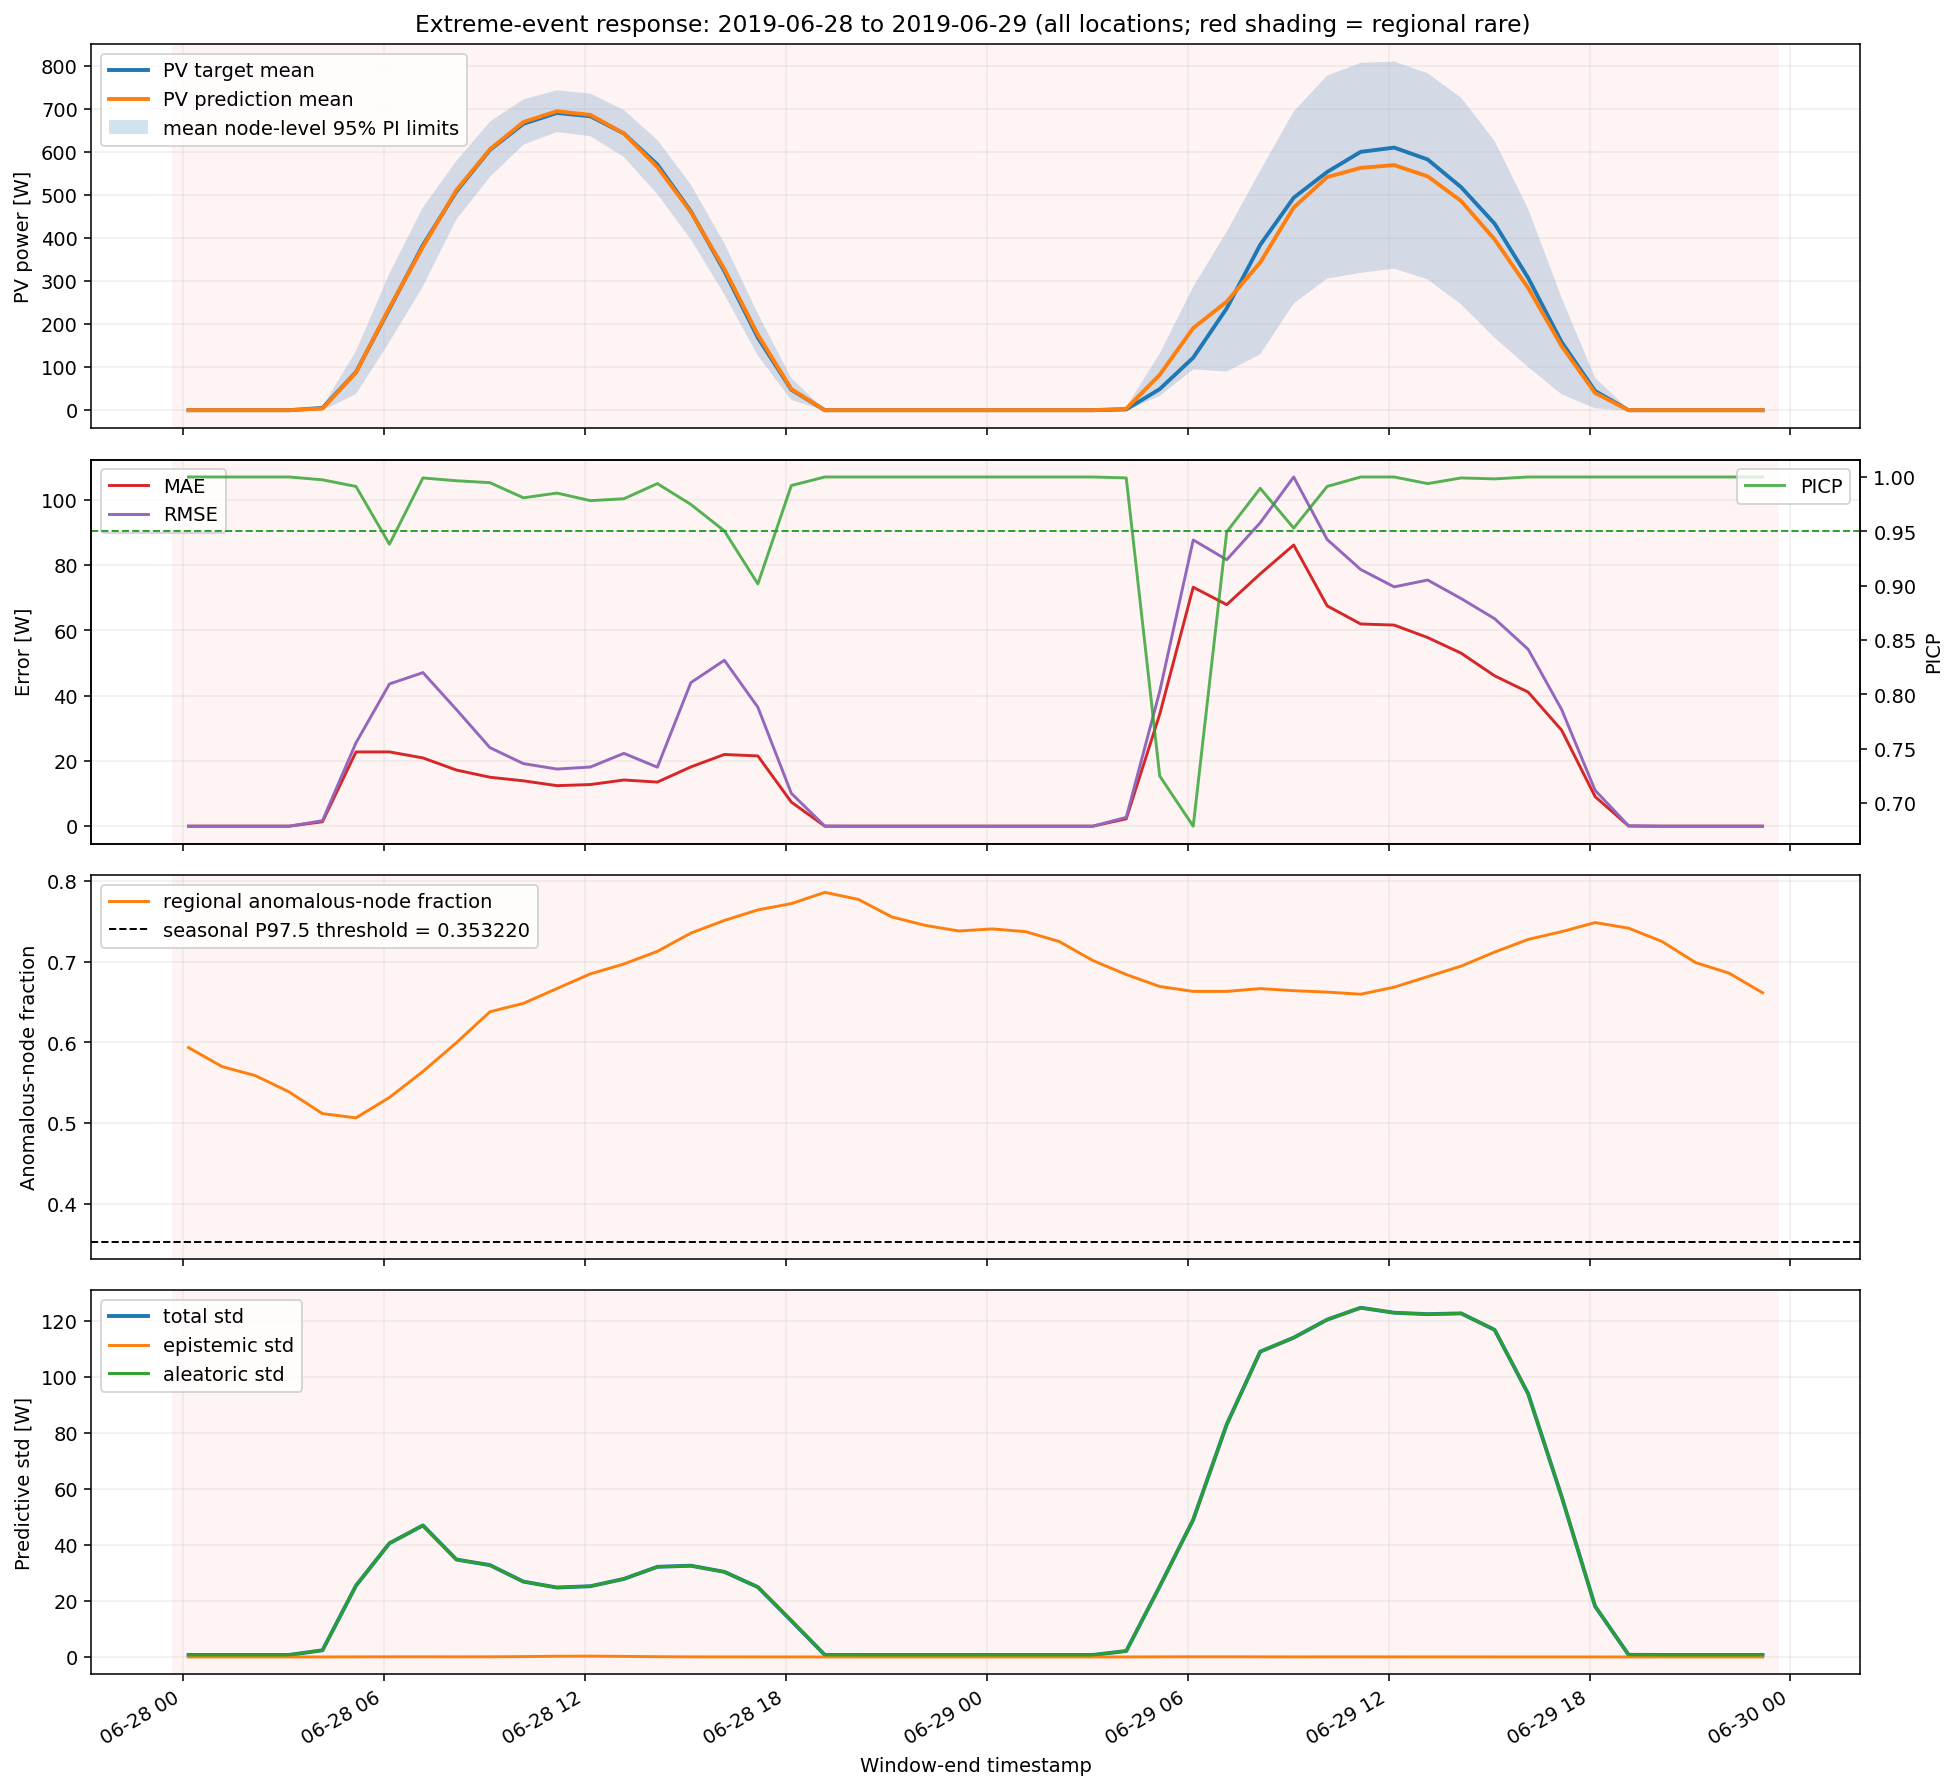

CSV orario: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/extreme_event_20190628_20190629_hourly.csv
CSV riepilogo: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/extreme_event_20190628_20190629_summary.csv


In [5]:
june_event = pipe.build_extreme_event_diagnostic(
    out_dir,
    start='2019-06-28',
    end='2019-06-30',  # estremo escluso: include tutto il 28 e 29 giugno
    figure_subdir='june_extreme_event',
)
print(f"Righe usate (nessun campionamento): {june_event['rows_used']:,}")
print('Soglia regionale stagionale:', june_event['regional_threshold'])
display(june_event['summary'])
display(june_event['hourly'])
display(Image(filename=str(june_event['figure_path'])))
print('CSV orario:', june_event['hourly_path'])
print('CSV riepilogo:', june_event['summary_path'])

## Normale 2019 vs 28 giugno vs 29 giugno

Boxplot, istogrammi e metriche usano tutte le predizioni diurne valide e sono separati nelle fasce 0–20%, 20–40%, 40–60%, 60–80% e 80–100% della potenza di riferimento.

,bin,category,count,mae,rmse,mpiw,nmpil,picp,clc
0,daytime_0_20_pct,normal_2019,1853036,39.404498,67.117756,166.551778,0.186747,0.941304,0.388696
1,daytime_0_20_pct,2019-06-28,3870,23.881705,52.356328,76.300575,0.085552,0.930491,0.187525
2,daytime_0_20_pct,2019-06-29,4104,45.137272,70.884725,137.854655,0.154570,0.824318,0.633611
3,daytime_20_40_pct,normal_2019,826945,46.193109,68.895114,254.599529,0.285470,0.947061,0.578593
4,daytime_20_40_pct,2019-06-28,1966,11.312399,18.334750,118.850530,0.133261,0.995931,0.221402
5,daytime_20_40_pct,2019-06-29,2379,50.007814,73.439215,313.294284,0.351282,0.970156,0.644287
6,daytime_40_60_pct,normal_2019,712727,46.445237,69.593098,278.889988,0.312706,0.960443,0.597359
7,daytime_40_60_pct,2019-06-28,2200,13.136344,22.609148,139.007531,0.155862,0.995909,0.258972
8,daytime_40_60_pct,2019-06-29,2783,54.421662,70.678385,451.639297,0.506402,0.988502,0.864503
9,daytime_60_80_pct,normal_2019,640750,45.250091,75.061982,273.228459,0.306358,0.967204,0.568771


CSV metriche: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/extreme_event_comparison_june_extreme_28_29_metrics.csv
Grafici creati: 20


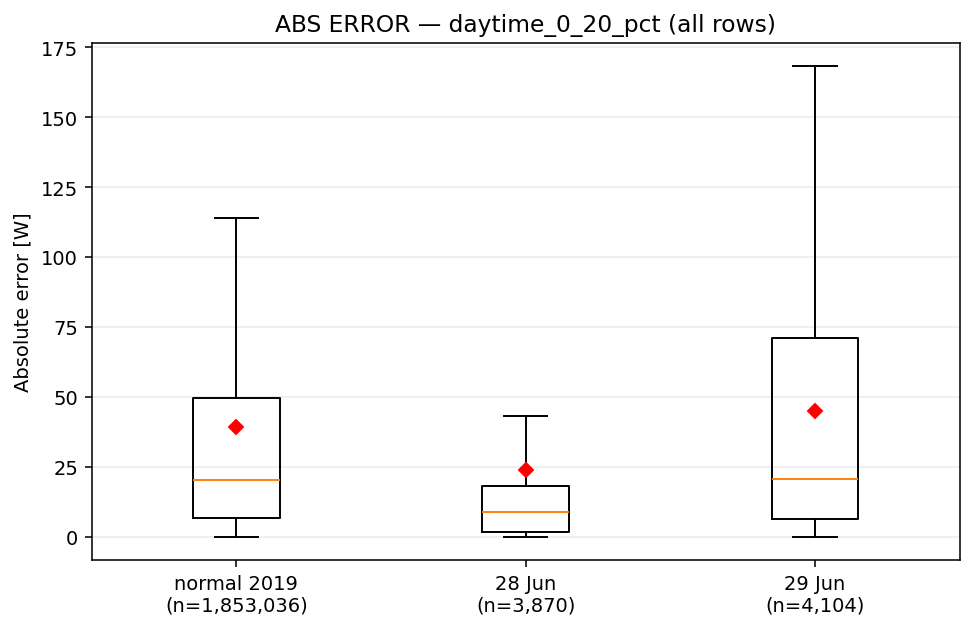

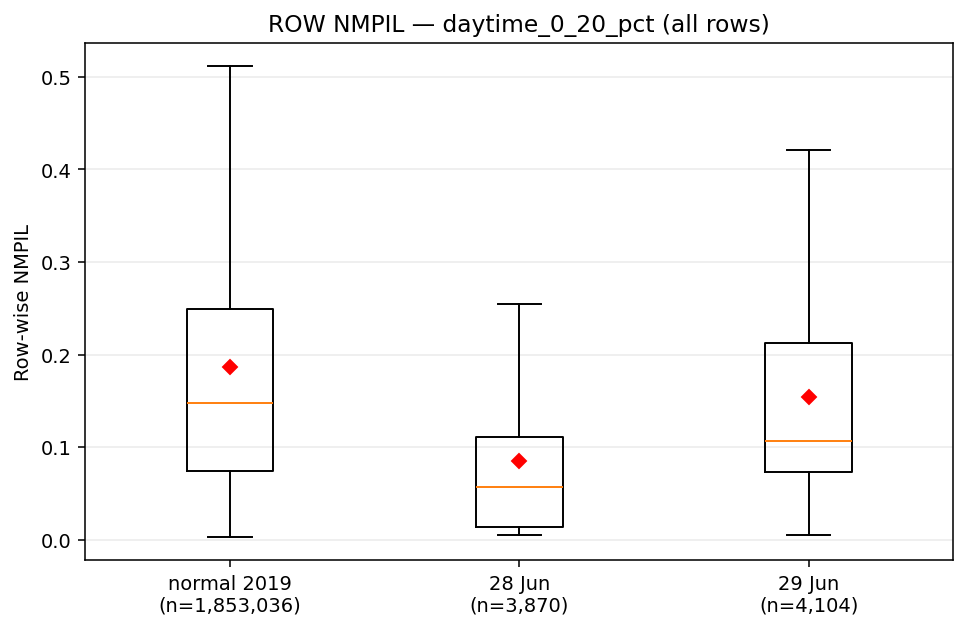

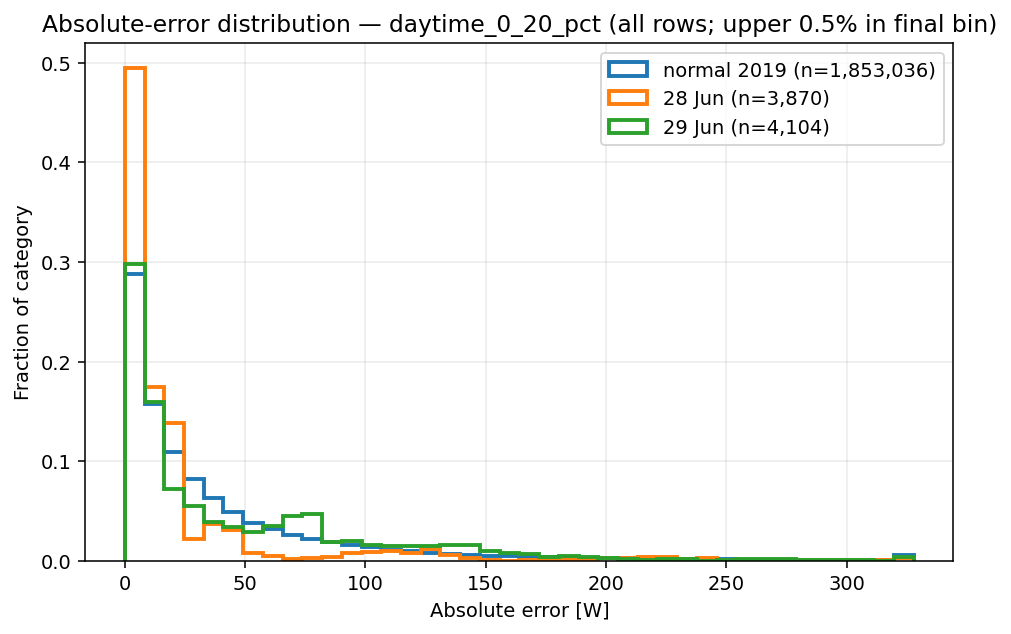

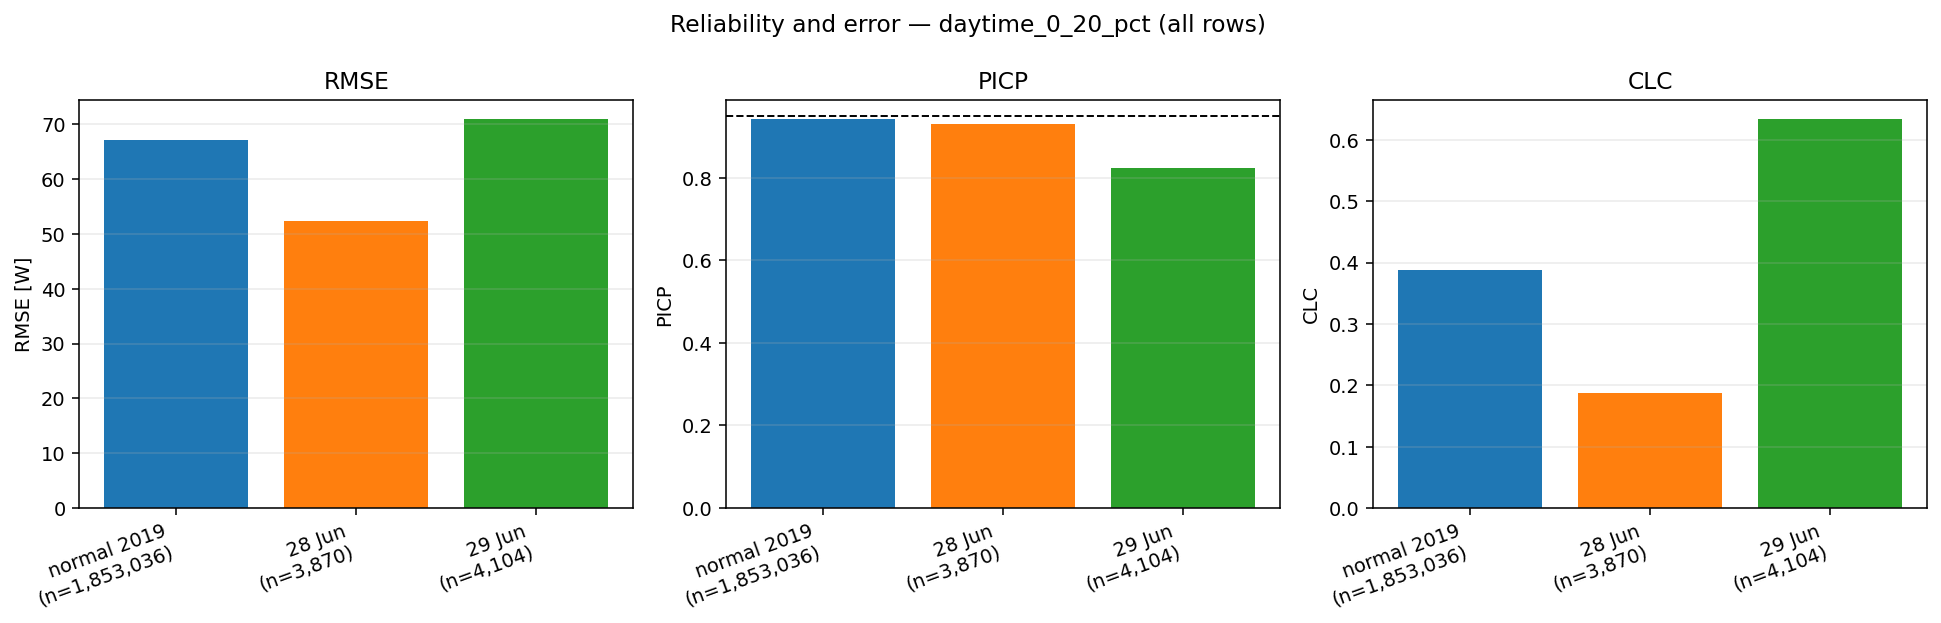

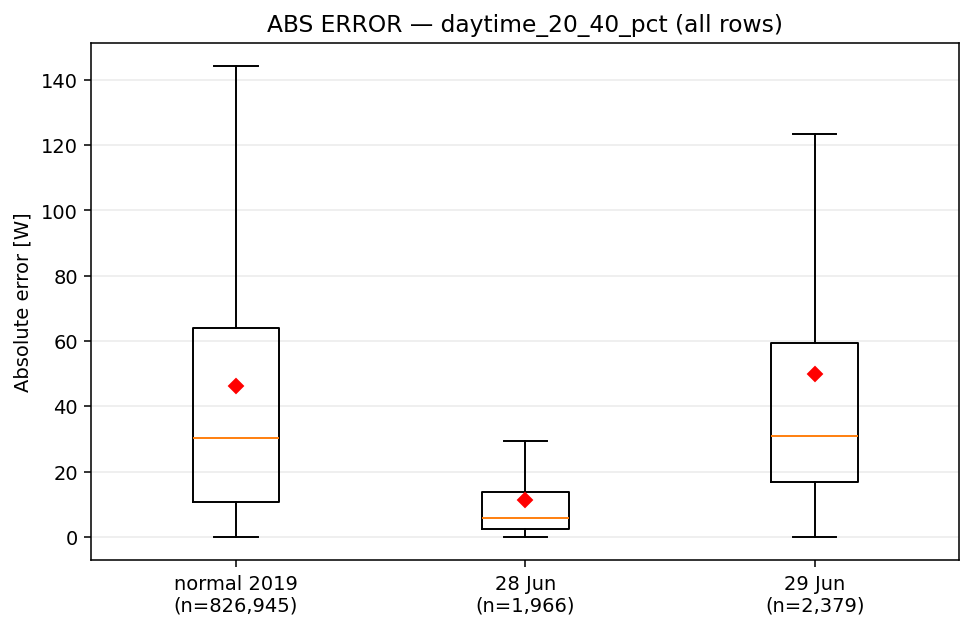

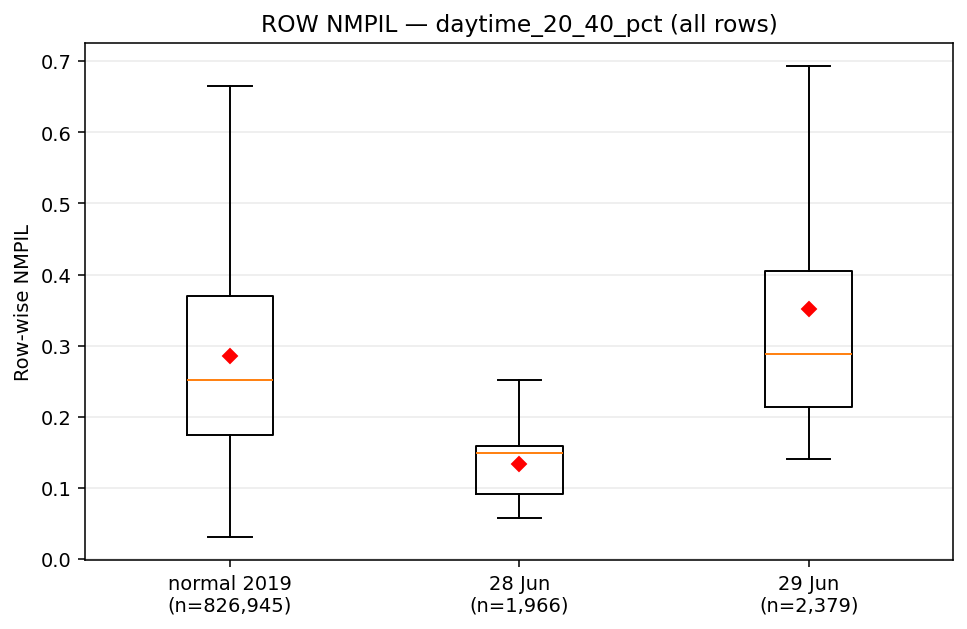

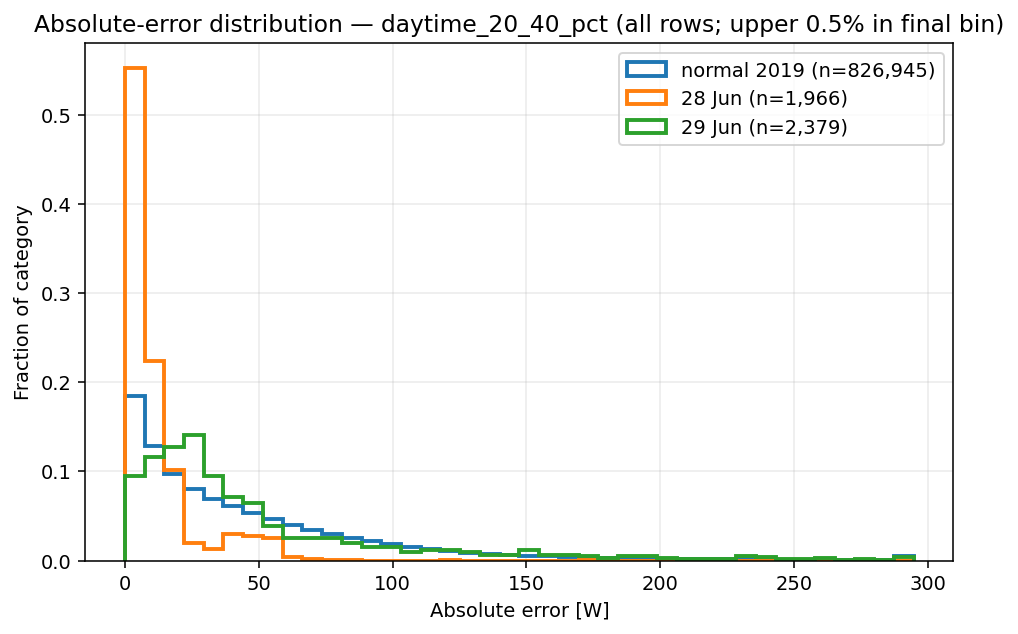

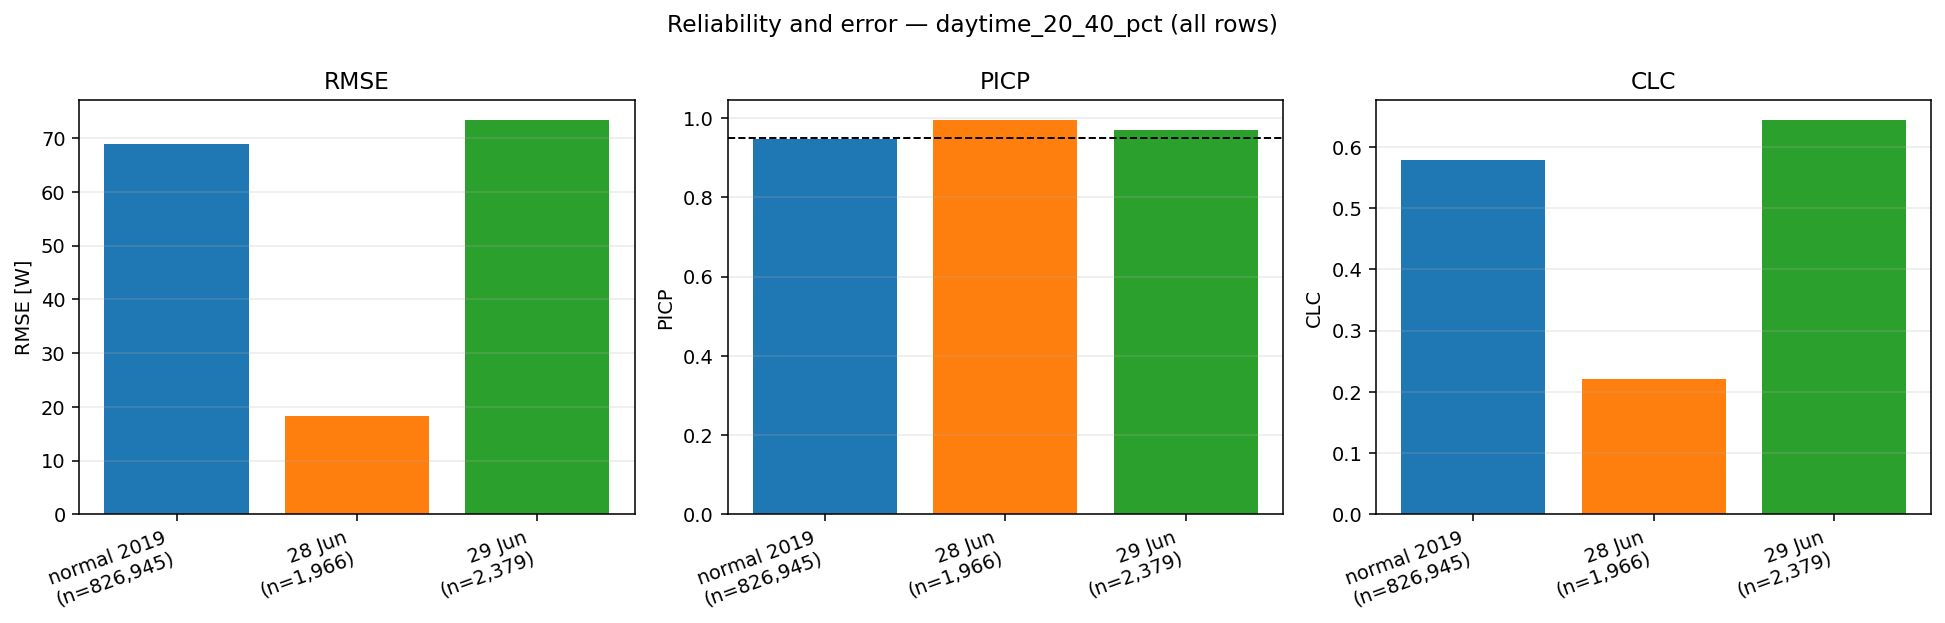

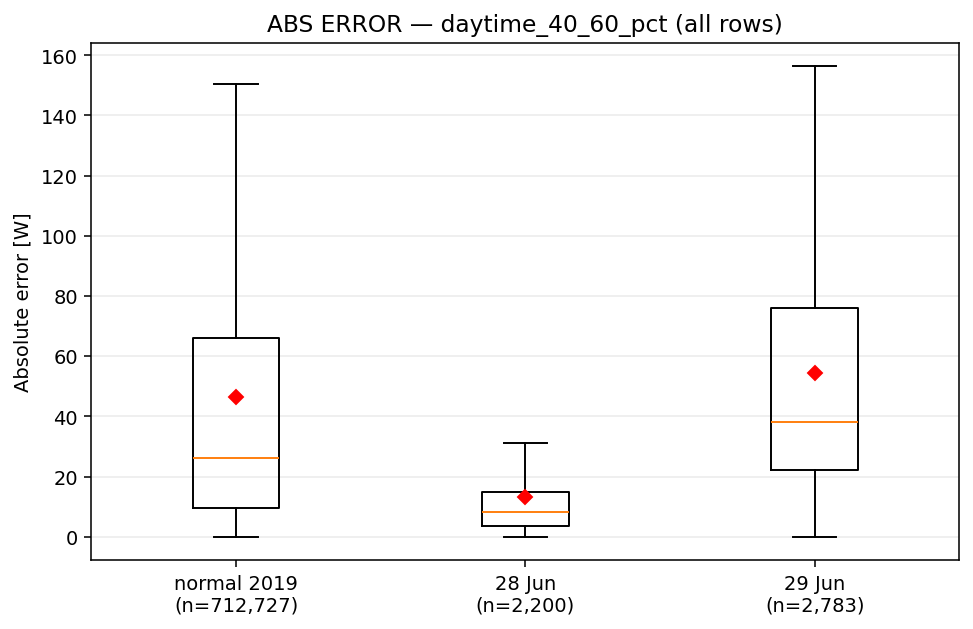

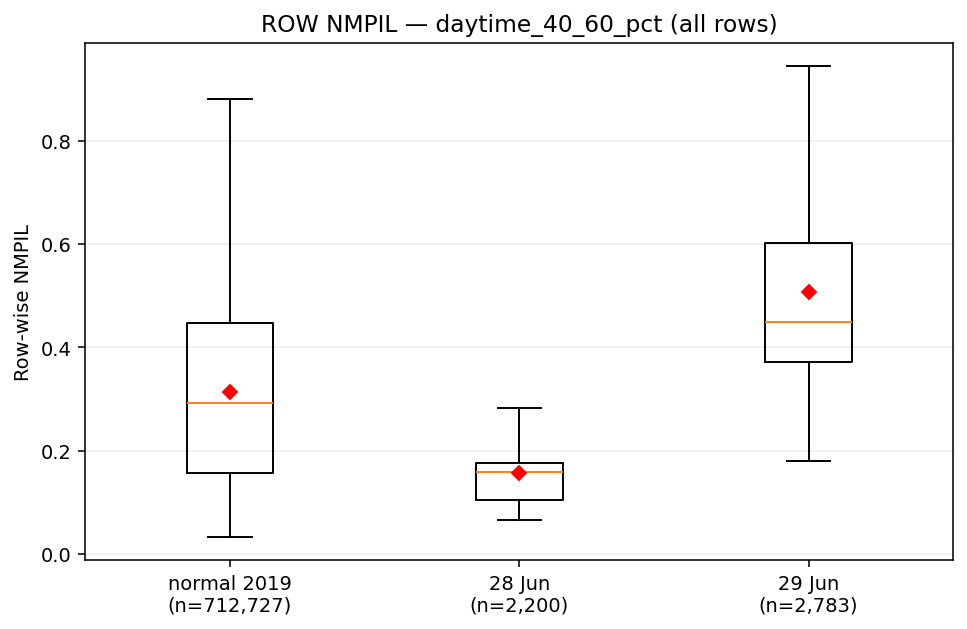

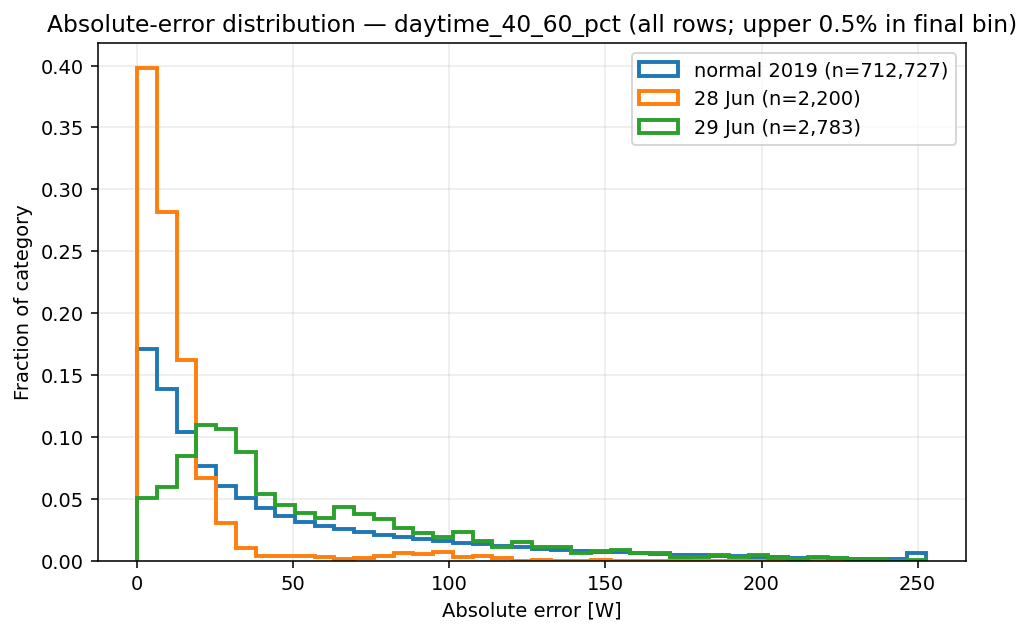

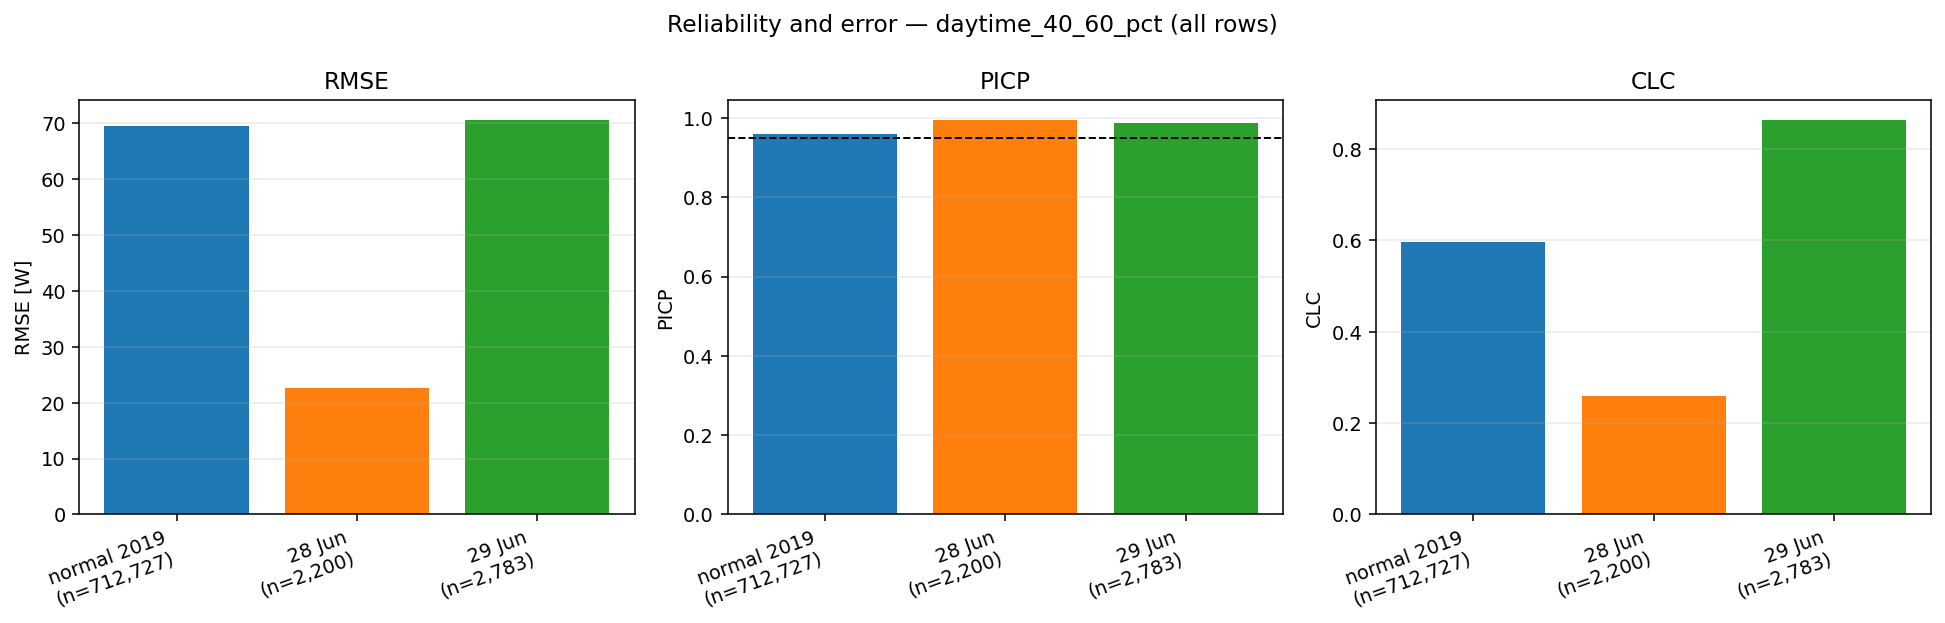

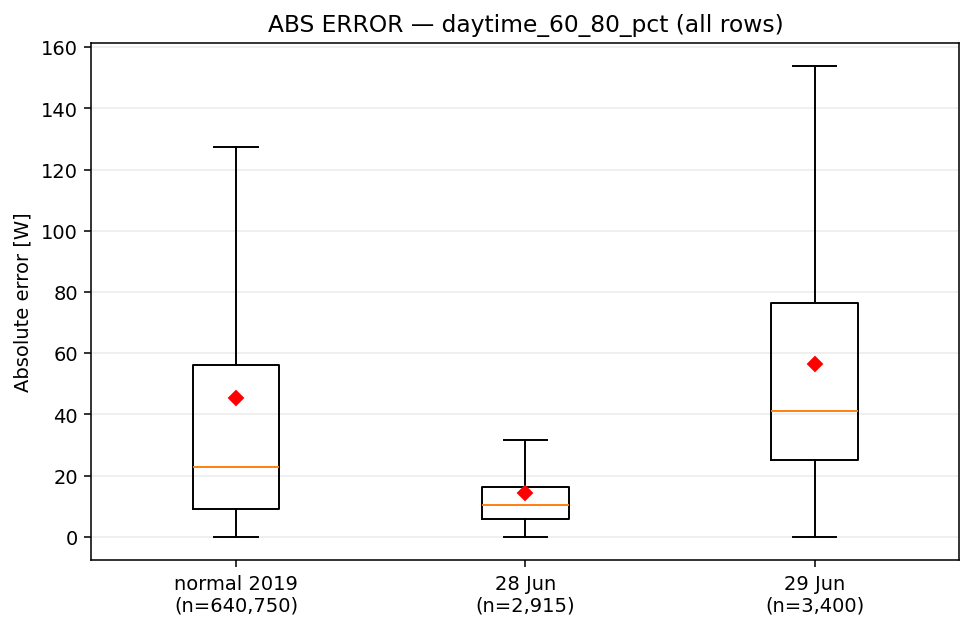

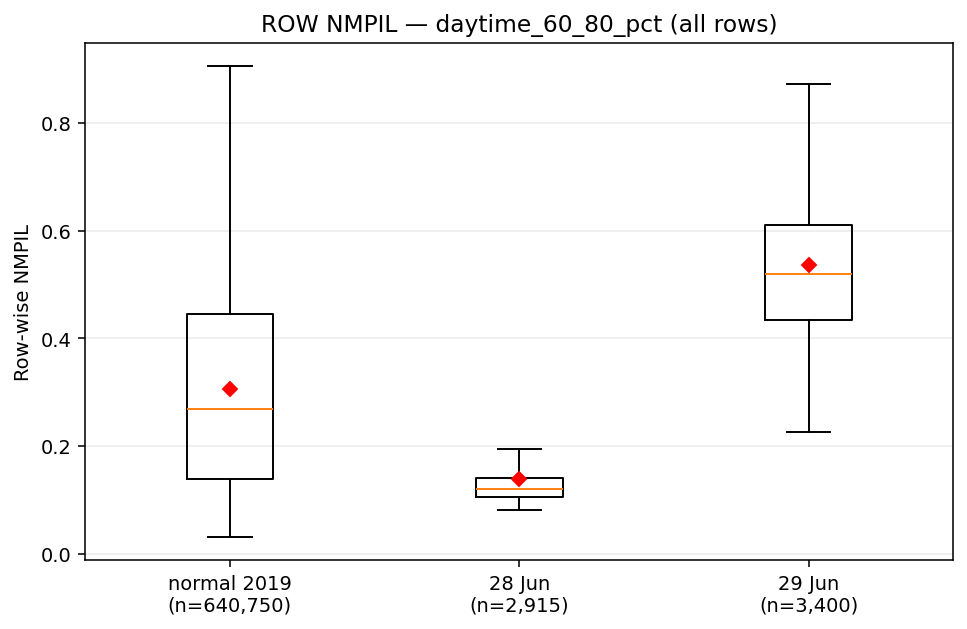

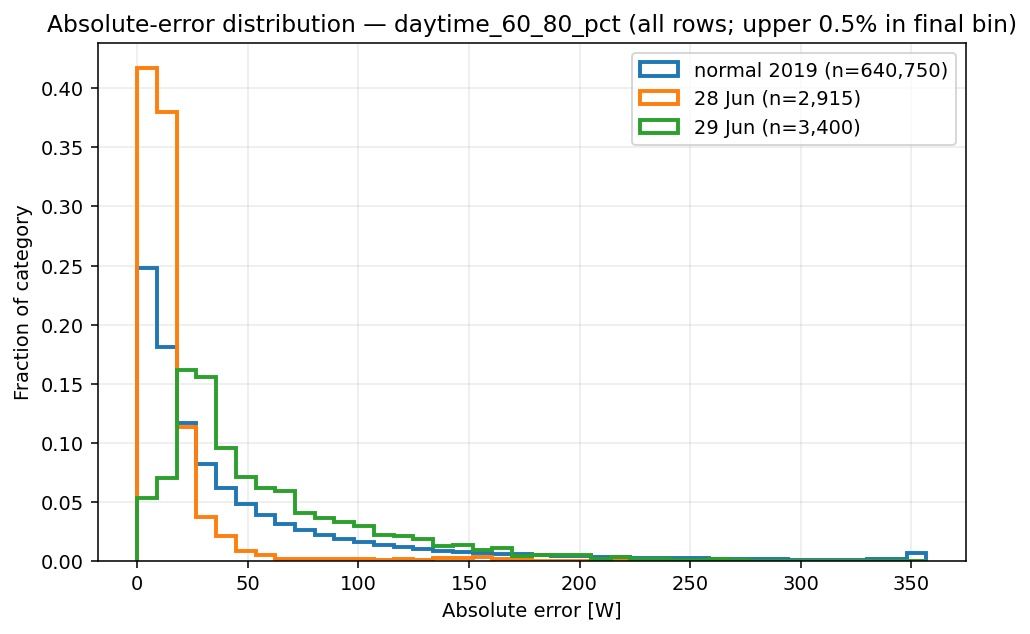

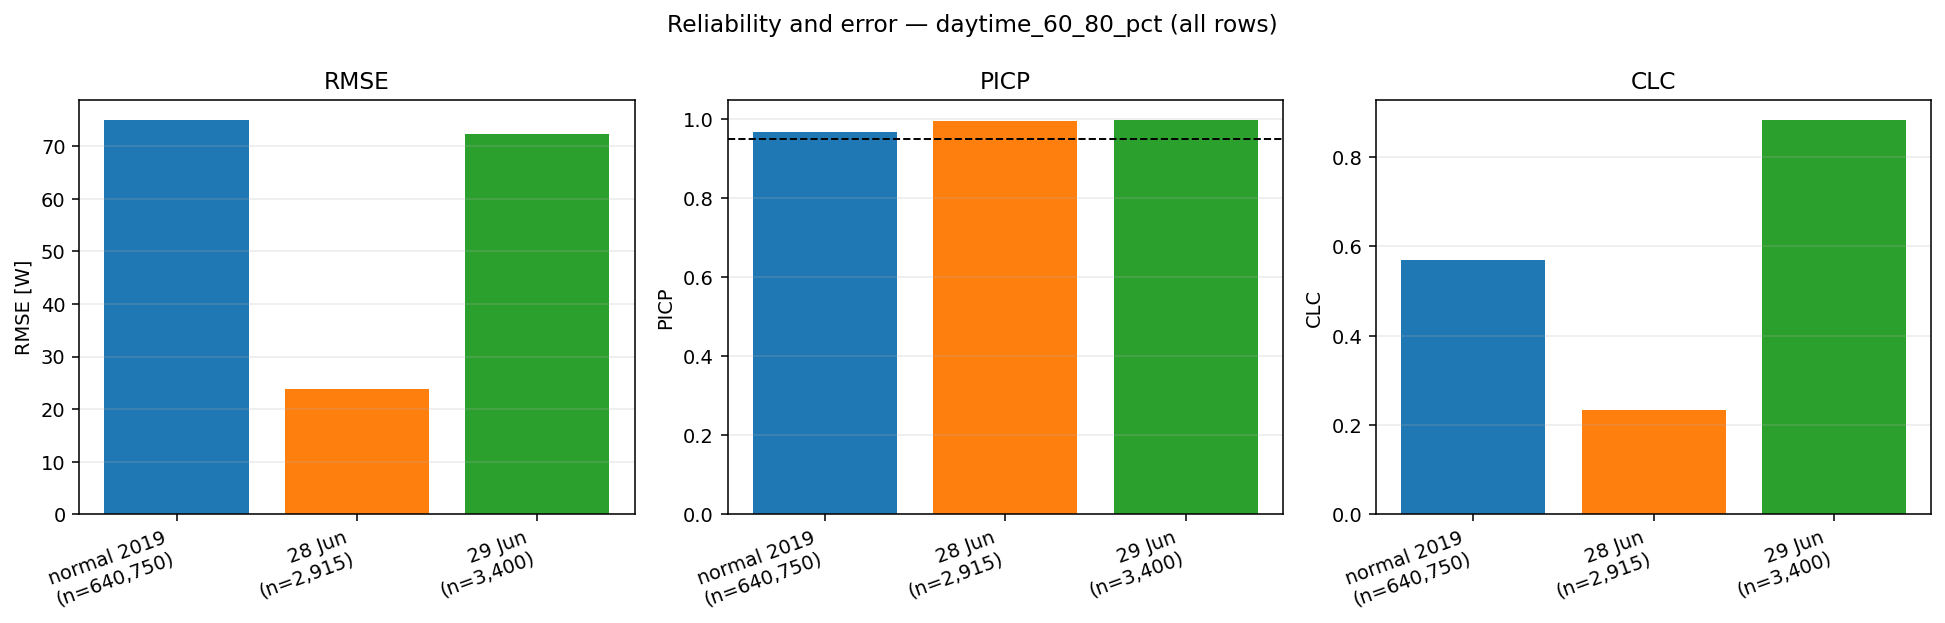

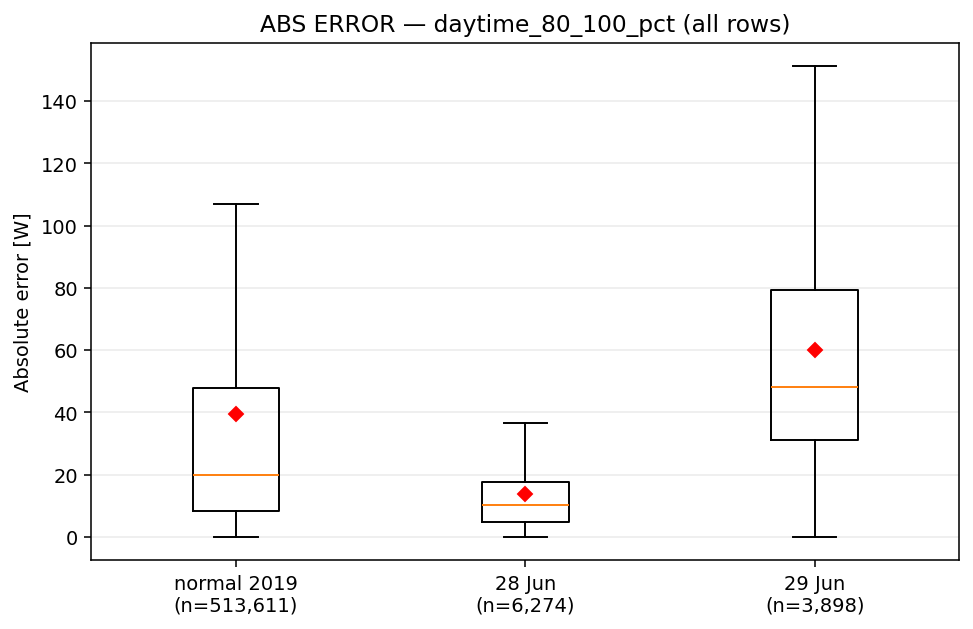

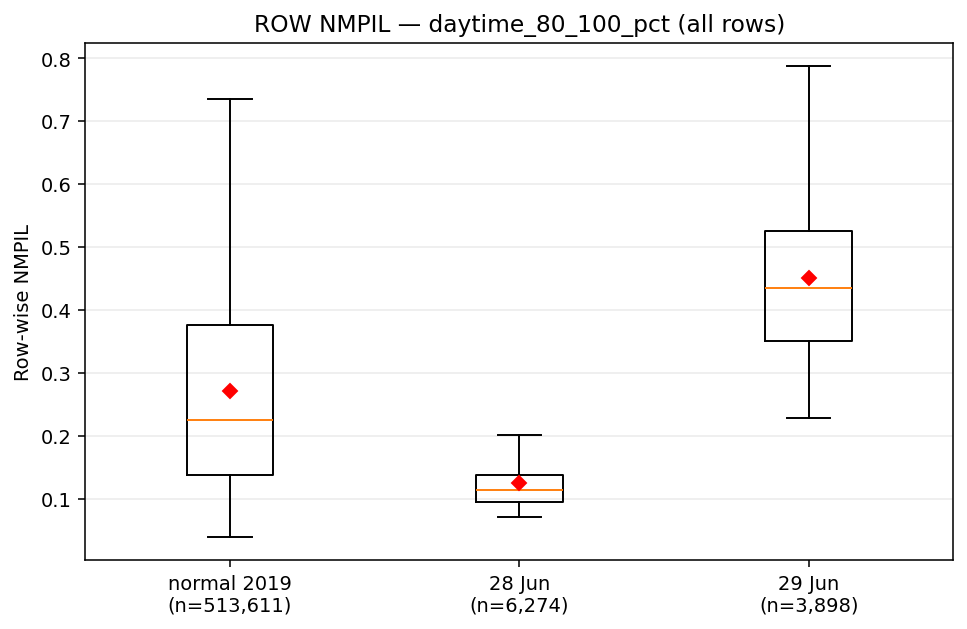

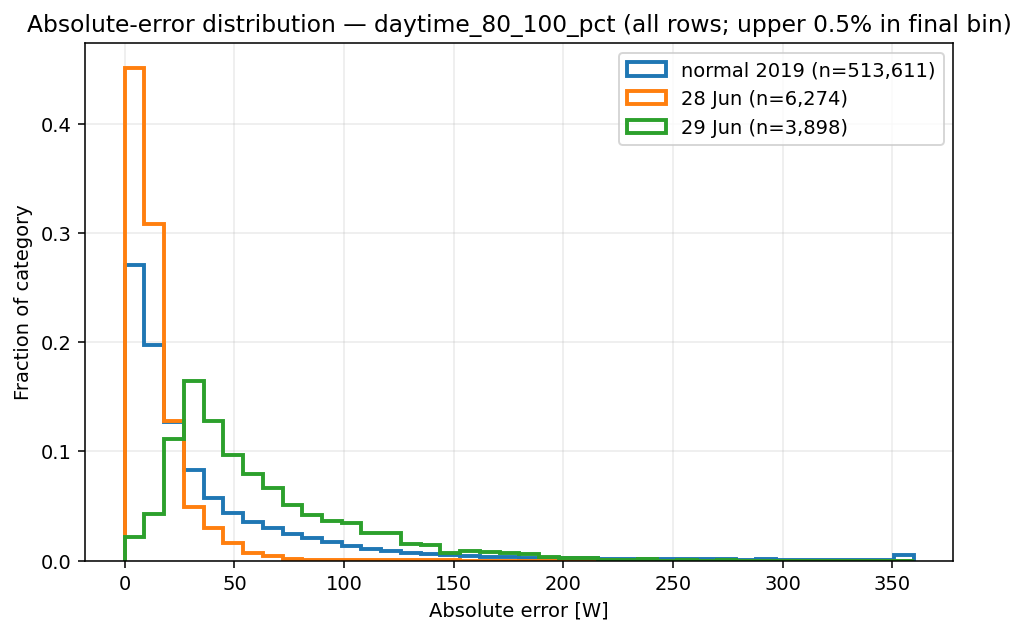

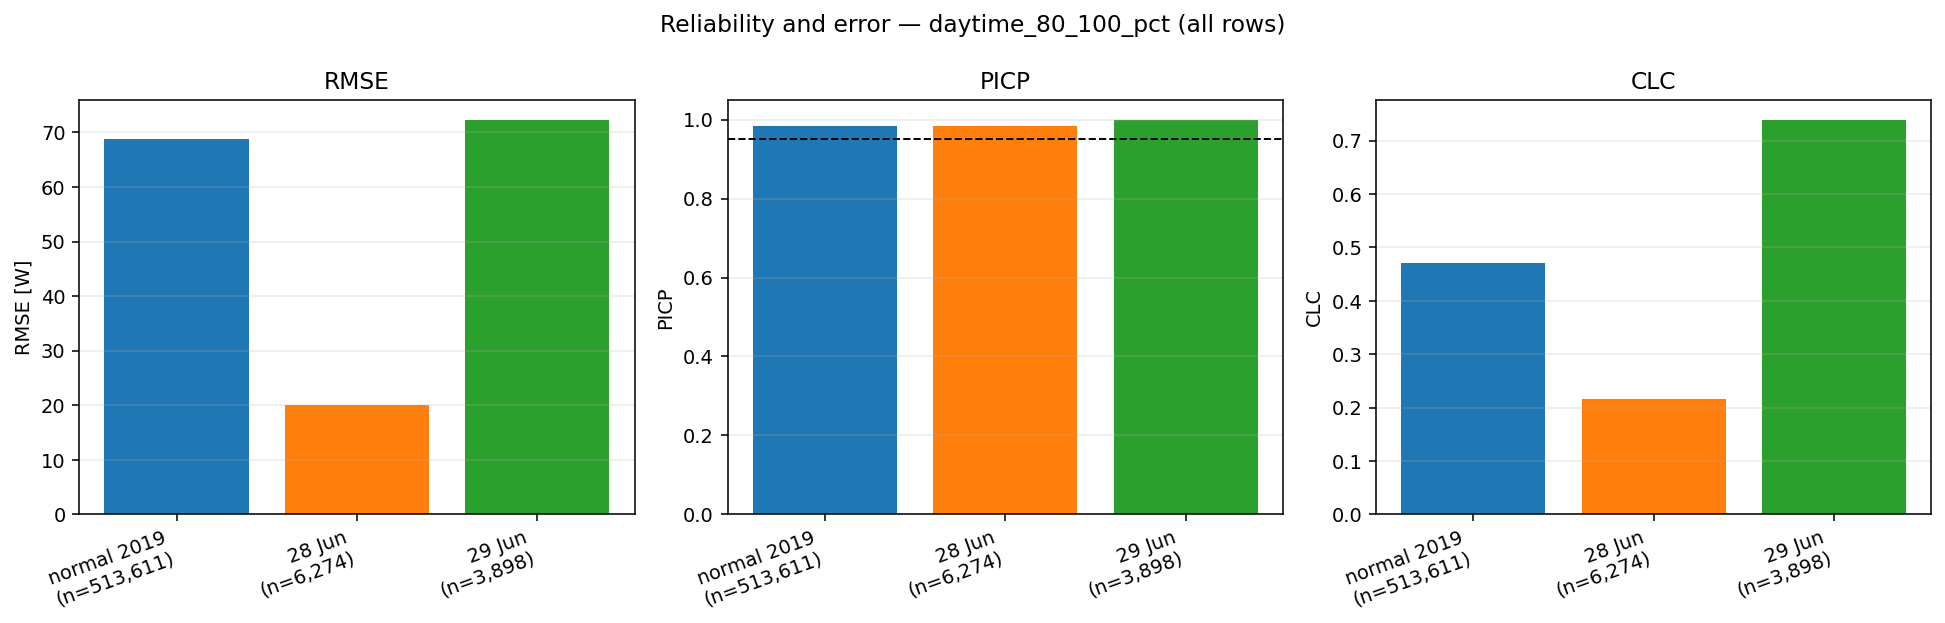

In [6]:
june_comparison = pipe.build_extreme_event_comparison_figures(
    out_dir,
    event_dates=('2019-06-28', '2019-06-29'),
    comparison_name='june_extreme_28_29',
    figure_subdir='june_extreme_event',
)
display(june_comparison['metrics'])
print('CSV metriche:', june_comparison['metrics_path'])
print('Grafici creati:', len(june_comparison['figure_paths']))
for figure_path in june_comparison['figure_paths'].values():
    display(Image(filename=str(figure_path)))